In [1]:
import tensorflow as tf
from tensorflow import keras
import os
import pandas as pd
from tensorflow.keras.applications import ResNet50V2
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PATH = 'datasets/ISIC_2020_corrected'
os.listdir(PATH)

['subset.csv',
 'test_split.csv',
 'train',
 'train.csv',
 'train_resized',
 'train_sd_split.csv',
 'train_split.csv',
 'val_split.csv']

In [155]:
train = pd.read_csv(f'{PATH}/subset.csv')
val = pd.read_csv(f'{PATH}/val_split.csv')
test = pd.read_csv(f'{PATH}/test_split.csv')
train.shape, val.shape

((2319, 9), (4969, 9))

In [156]:
train.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_8130007,IP_5229014,IL_1982348,male,55.0,upper extremity,unknown,benign,0
1,ISIC_4820993,IP_3713422,IL_2860029,male,50.0,torso,unknown,benign,0
2,ISIC_6859051,IP_9927968,IL_7824946,male,35.0,lower extremity,unknown,benign,0
3,ISIC_3216482,IP_4204657,IL_0820225,female,40.0,lower extremity,unknown,benign,0
4,ISIC_7381220,IP_3434100,IL_4512578,female,60.0,torso,unknown,benign,0


In [157]:
BATCH_SIZE = 64
AUTO = tf.data.experimental.AUTOTUNE

def decode(name, label):
    img = tf.io.read_file(name)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 50.0)
    return img, label
    
def load_ds_augment(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.map(augment, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds

def load_ds(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds

In [158]:
train_ds = load_ds_augment(train)
val_ds = load_ds_augment(val)
test_ds = load_ds(test)

In [159]:
len(train_ds)*64

2368

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

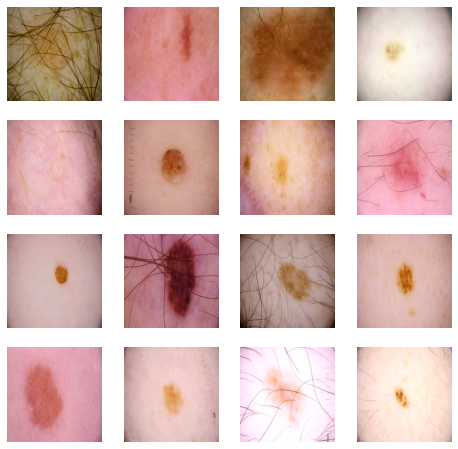

In [134]:
import random

r,c = 4, 4

fig = plt.figure(figsize=(2*c, 2*r))
for _r in range(r):
    for _c in range(c):
        plt.subplot(r, c, _r*c + _c + 1)
        for imgs, labels in train_ds.take(1):
            img = imgs[0].numpy() / 255
            plt.imshow(img)
            plt.axis(False)
plt.show()

In [135]:
IMAGE_SIZE = (256, 256, 3)

encoder = ResNet50V2(
    include_top=False,
    input_shape=IMAGE_SIZE,
    weights='imagenet'
)
encoder.trainable = False

inputs = keras.Input(shape=IMAGE_SIZE)
x = keras.layers.Rescaling(1./255)(inputs)
x = encoder(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 rescaling_3 (Rescaling)     (None, 256, 256, 3)       0         
                                                                 
 resnet50v2 (Functional)     (None, 8, 8, 2048)        23564800  
                                                                 
 global_average_pooling2d_3   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_3 (Dense)             (None, 1)                 2049      
                                                                 
Total params: 23,566,849
Trainable params: 2,049
Non-trainable params: 23,564,800
___________________________________________

In [136]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(name="auc")]
)

In [137]:
filepath = 'models/checkpoints/baseline2'
cb = tf.keras.callbacks.ModelCheckpoint(
    filepath = filepath,
    monitor="val_auc",
    verbose=0,
    save_best_only=True,
    save_weights_only=True,
    mode="max"
)

In [138]:
history = model.fit(train_ds,
                    epochs=10,
                    validation_data=val_ds,
                    #validation_steps=10,
                    callbacks=[cb]
                   )

Epoch 1/10
37/37 [==============================] - 20s 501ms/step - loss: 0.1441 - auc: 0.4192 - val_loss: 0.1048 - val_auc: 0.4752
Epoch 2/10
37/37 [==============================] - 16s 454ms/step - loss: 0.0976 - auc: 0.5108 - val_loss: 0.0885 - val_auc: 0.6183
Epoch 3/10
37/37 [==============================] - 16s 448ms/step - loss: 0.0855 - auc: 0.6594 - val_loss: 0.0837 - val_auc: 0.7039
Epoch 4/10
37/37 [==============================] - 16s 448ms/step - loss: 0.0783 - auc: 0.7591 - val_loss: 0.0816 - val_auc: 0.7550
Epoch 5/10
37/37 [==============================] - 17s 462ms/step - loss: 0.0736 - auc: 0.8232 - val_loss: 0.0796 - val_auc: 0.7573
Epoch 6/10
37/37 [==============================] - 17s 475ms/step - loss: 0.0694 - auc: 0.8597 - val_loss: 0.0791 - val_auc: 0.7841
Epoch 7/10
37/37 [==============================] - 17s 462ms/step - loss: 0.0659 - auc: 0.8877 - val_loss: 0.0781 - val_auc: 0.7966
Epoch 8/10
37/37 [==============================] - 16s 445ms/step - 

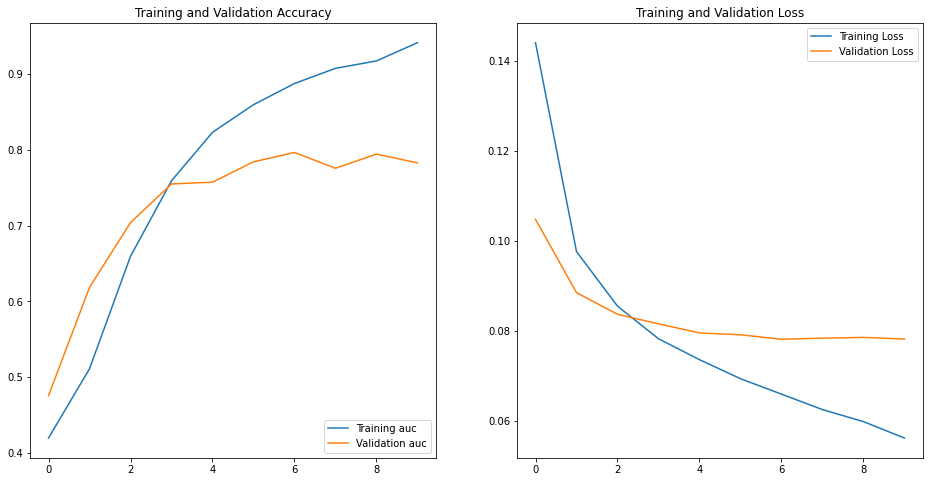

In [139]:
auc = history.history['auc']
val_auc = history.history['val_auc']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, auc, label='Training auc')
plt.plot(epochs_range, val_auc, label='Validation auc')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [160]:
results = model.evaluate(test_ds)
print(results)

78/78 [==============================] - 11s 130ms/step - loss: 0.0783 - auc: 0.8205
[0.07834018766880035, 0.8205146789550781]


In [141]:
model.load_weights(filepath)
model.save('models/baseline2DataAugmentation.h5')